# 🔊 Listening to Extinction — Part 3
## The Changing Voice: Acoustic Drift Over Time

> *Code Beyond the Earth | IDB 2026*

In Part 1, we tracked where Turkey's birds are moving geographically.  
In Part 2, we learned that machines identify birds not by tone, but by variability.  
In Part 3, we ask the hardest question: **does a species start sounding different before it disappears?**

### Hypothesis
A species under ecological pressure doesn't just move. It sounds different.  
Habitat loss, fragmentation, and climate stress may alter the acoustic environment —  
and therefore the calls themselves, or at least the population of calls we record.

### Pipeline:
1. Split each species' MFCC recordings into time windows
2. Compute **cosine similarity** between early and late acoustic profiles
3. Detect **anomalous recordings** using Isolation Forest
4. Visualize acoustic drift trajectories over time
5. Cross-reference with Part 1 geographic shift data

### Input files:
- `turkey_birds_mfcc_full.csv` — full MFCC feature matrix with dates
- `turkey_birds_shift_all.csv` — geographic shift summary from Part 1
- `rf_model.pkl` — trained Random Forest from Part 2

---

## 0. Setup

Same environment as Parts 1 and 2, plus `scipy` for cosine similarity.

In [2]:
!pip install scikit-learn scipy pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from scipy.spatial.distance import cosine
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.style.use('dark_background')
COLORS = {
    'loser':  '#FF6B6B',
    'winner': '#6BFF9E',
    'silent': '#A8A8B3',
    'other':  '#30363D',
    'bg':     '#0D1117',
    'accent': '#58A6FF',
    'anomaly':'#FFD700'
}

FOCUS_META = {
    'Otis tarda':             ('Büyük Toy',        'loser'),
    'Alectoris chukar':       ('Kınalı Keklik',    'loser'),
    'Coturnix coturnix':      ('Bıldırcın',        'loser'),
    'Pica pica':              ('Saksağan',         'winner'),
    'Apus apus':              ('Ebabil',           'winner'),
    'Buteo buteo':            ('Kızıl Şahin',      'winner'),
    'Aegypius monachus':      ('Kara Akbaba',      'silent'),
    'Melanocorypha calandra': ('Bozkır Toygarı',   'silent'),
    'Ficedula semitorquata':  ('Alaca Sinekkapan', 'silent'),
}

FEATURE_COLS = (
    [f'mfcc_mean_{i}'  for i in range(13)] +
    [f'mfcc_std_{i}'   for i in range(13)] +
    [f'mfcc_delta_{i}' for i in range(13)]
)

print('Setup complete.')

Setup complete.


## 1. Load Data

Load MFCC features and parse recording years.  
We filter to species with **≥5 years** of recordings — minimum for a meaningful drift signal.

We also load the geographic shift data from Part 1 to cross-reference later.

In [3]:
# Load MFCC data
mfcc_df = pd.read_csv('turkey_birds_mfcc_full.csv')
mfcc_df['year'] = pd.to_datetime(mfcc_df['date'], errors='coerce').dt.year
mfcc_df = mfcc_df.dropna(subset=['year'] + FEATURE_COLS)
mfcc_df['year'] = mfcc_df['year'].astype(int)

# Load geographic shift from Part 1
shift_df = pd.read_csv('turkey_birds_shift_all.csv')

# Filter: species with ≥5 distinct years
year_counts   = mfcc_df.groupby('scientific_name')['year'].nunique()
valid_species = year_counts[year_counts >= 5].index
mfcc_valid    = mfcc_df[mfcc_df['scientific_name'].isin(valid_species)].copy()

print(f'Total recordings loaded    : {len(mfcc_df):,}')
print(f'Year range                 : {mfcc_df["year"].min()} – {mfcc_df["year"].max()}')
print(f'Species with ≥5 years      : {len(valid_species)}')
print(f'Recordings in analysis     : {len(mfcc_valid):,}')
print()
print('Top 10 species by year coverage:')
top10 = year_counts[year_counts >= 5].sort_values(ascending=False).head(10)
for sp, n in top10.items():
    en = mfcc_df[mfcc_df['scientific_name']==sp]['english_name'].iloc[0] if 'english_name' in mfcc_df.columns else sp
    print(f'  {en:35} {n} years')

Total recordings loaded    : 926
Year range                 : 1993 – 2026
Species with ≥5 years      : 56
Recordings in analysis     : 741

Top 10 species by year coverage:
  Common Blackbird                    11 years
  Cretzschmar's Bunting               10 years
  Eastern Bonelli's Warbler           10 years
  Eastern Orphean Warbler             9 years
  Isabelline Wheatear                 9 years
  Eastern Olivaceous Warbler          9 years
  Krüper's Nuthatch                   9 years
  Red-fronted Serin                   9 years
  Eurasian Scops Owl                  9 years
  Common Chaffinch                    8 years


## 2. Acoustic Drift — Cosine Similarity Over Time

**Method:** For each species, we compute a **mean MFCC vector per year** (the annual acoustic centroid).  
Then we measure cosine similarity between each year's centroid and the **earliest year's centroid**.

- Similarity = 1.0 → identical acoustic profile to the baseline
- Similarity < 1.0 → the species sounds different from its earliest recordings
- Declining trend → systematic acoustic drift

This is the temporal equivalent of Part 1's geographic centroid shift.

In [4]:
def compute_acoustic_drift(df, feature_cols):
    """
    For each species, compute annual mean MFCC vector
    and cosine similarity to the earliest year's vector.

    Returns:
        drift_df: long-format DataFrame with columns
                  [scientific_name, english_name, year,
                   similarity, n_recordings, is_baseline]
    """
    rows = []

    for sci_name, group in df.groupby('scientific_name'):
        en_name = group['english_name'].iloc[0] if 'english_name' in group.columns else sci_name

        # Annual mean MFCC vector
        annual = (
            group.groupby('year')[feature_cols]
            .agg(['mean', 'count'])
        )
        # Flatten multi-index
        annual_mean = group.groupby('year')[feature_cols].mean()
        annual_n    = group.groupby('year').size().rename('n')

        years = sorted(annual_mean.index)
        baseline_vec = annual_mean.loc[years[0]].values  # earliest year

        for year in years:
            vec = annual_mean.loc[year].values

            # Cosine similarity (1 - cosine distance)
            sim = 1 - cosine(baseline_vec, vec)

            rows.append({
                'scientific_name': sci_name,
                'english_name':    en_name,
                'year':            year,
                'similarity':      sim,
                'n_recordings':    annual_n.get(year, 0),
                'is_baseline':     year == years[0],
                'baseline_year':   years[0],
                'years_span':      years[-1] - years[0],
            })

    return pd.DataFrame(rows)


drift_df = compute_acoustic_drift(mfcc_valid, FEATURE_COLS)

print(f'Drift analysis complete: {len(drift_df)} year-species data points')
print()

# Summary: most drifted species
drift_summary = (
    drift_df[~drift_df['is_baseline']]
    .groupby(['scientific_name', 'english_name'])
    ['similarity'].mean()
    .reset_index()
    .sort_values('similarity')
)

print('Most acoustically drifted species (lowest avg similarity to baseline):')
for _, row in drift_summary.head(10).iterrows():
    print(f"  {row['english_name'] or row['scientific_name']:35} avg similarity: {row['similarity']:.4f}")

print()
print('Most acoustically stable species (highest avg similarity):')
for _, row in drift_summary.tail(5).iterrows():
    print(f"  {row['english_name'] or row['scientific_name']:35} avg similarity: {row['similarity']:.4f}")

Drift analysis complete: 385 year-species data points

Most acoustically drifted species (lowest avg similarity to baseline):
  Cetti's Warbler                     avg similarity: 0.9080
  Tawny Owl                           avg similarity: 0.9101
  Krüper's Nuthatch                   avg similarity: 0.9191
  Menetries's Warbler                 avg similarity: 0.9307
  Water Pipit                         avg similarity: 0.9349
  House Sparrow                       avg similarity: 0.9366
  Crested Lark                        avg similarity: 0.9428
  Delicate Prinia                     avg similarity: 0.9431
  Hooded Crow                         avg similarity: 0.9444
  Horned Lark                         avg similarity: 0.9457

Most acoustically stable species (highest avg similarity):
  Rock Sparrow                        avg similarity: 0.9813
  Cinereous Bunting                   avg similarity: 0.9831
  Turkestan Short-toed Lark           avg similarity: 0.9834
  Lesser Whitethroat 

## 3. Visualize Acoustic Drift Trajectories

### 3.1 — All Species: Similarity Over Time

Each line = one species. Y-axis = cosine similarity to its earliest recording year.  
A declining line means the species sounds increasingly different from its historical baseline.

Focus species are highlighted in their category colors.

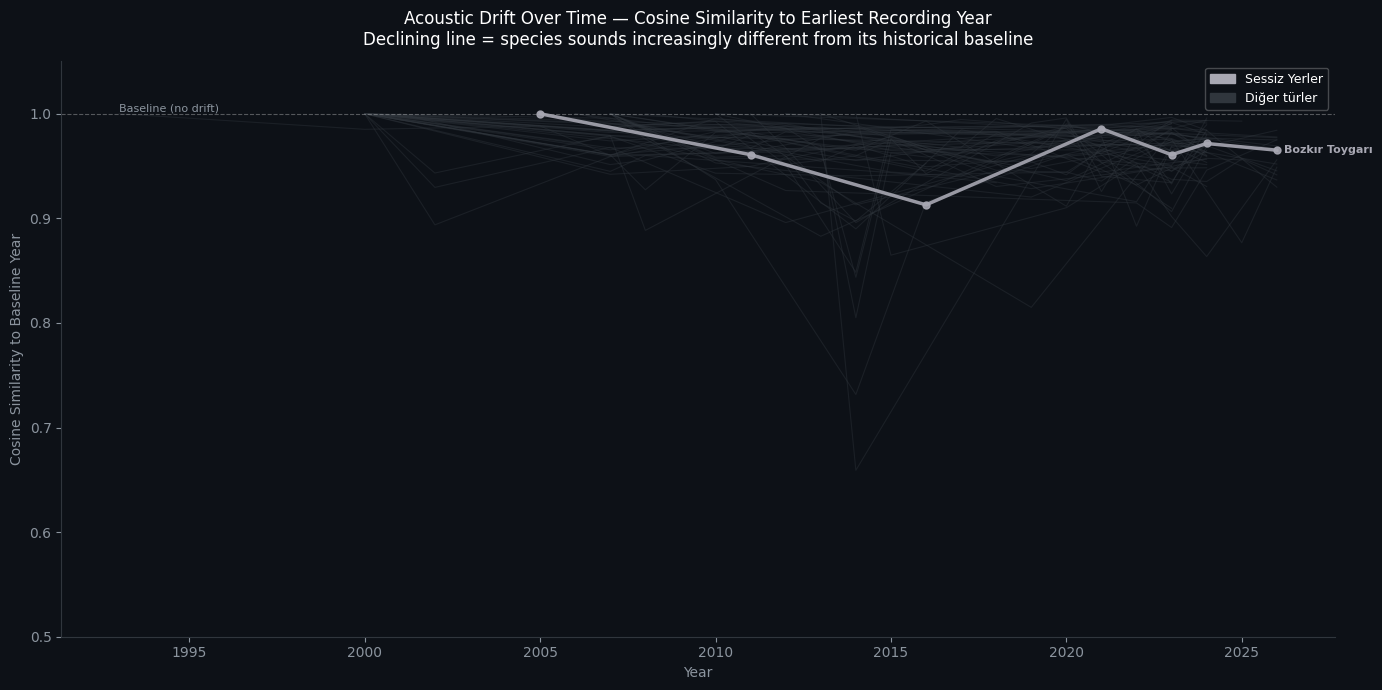

 Saved: turkey_birds_acoustic_drift.png


In [5]:
fig, ax = plt.subplots(figsize=(14, 7), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

# All species — faint background lines
for sci_name, group in drift_df.groupby('scientific_name'):
    if sci_name in FOCUS_META:
        continue
    group = group.sort_values('year')
    ax.plot(group['year'], group['similarity'],
            color='#30363D', alpha=0.4, linewidth=0.8)

# Focus species — highlighted
legend_patches = []
plotted_cats   = set()

for sci_name, (tr_name, category) in FOCUS_META.items():
    group = drift_df[drift_df['scientific_name'] == sci_name].sort_values('year')
    if len(group) < 2:
        continue
    color = COLORS[category]
    ax.plot(group['year'], group['similarity'],
            color=color, linewidth=2.5, alpha=0.9,
            marker='o', markersize=5, zorder=5)
    # Label at last point
    last = group.iloc[-1]
    ax.text(last['year'] + 0.2, last['similarity'], tr_name,
            fontsize=8, color=color, fontweight='bold', va='center')
    if category not in plotted_cats:
        legend_patches.append(mpatches.Patch(color=color, label={
            'loser': 'Kaybedenler', 'winner': 'Kazananlar', 'silent': 'Sessiz Yerler'
        }[category]))
        plotted_cats.add(category)

legend_patches.append(mpatches.Patch(color='#30363D', label='Diğer türler'))

# Reference line at 1.0
ax.axhline(1.0, color='white', linewidth=0.8, linestyle='--', alpha=0.3)
ax.text(drift_df['year'].min(), 1.002, 'Baseline (no drift)',
        fontsize=8, color='#8B949E')

ax.legend(handles=legend_patches, fontsize=9,
          framealpha=0.3, facecolor=COLORS['bg'])
ax.set_xlabel('Year', color='#8B949E', fontsize=10)
ax.set_ylabel('Cosine Similarity to Baseline Year', color='#8B949E', fontsize=10)
ax.tick_params(colors='#8B949E')
ax.set_ylim(0.5, 1.05)
ax.set_title(
    'Acoustic Drift Over Time — Cosine Similarity to Earliest Recording Year\n'
    'Declining line = species sounds increasingly different from its historical baseline',
    color='white', fontsize=12, pad=12
)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#30363D')

plt.tight_layout()
plt.savefig('turkey_birds_acoustic_drift.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print(' Saved: turkey_birds_acoustic_drift.png')

### 3.2 — Drift vs Geographic Shift: Does Acoustic Change Follow Movement?

Cross-referencing Part 1 and Part 3:  
Do species that are drifting geographically also drift acoustically?  

X-axis: geographic shift slope from Part 1 (positive = northward)  
Y-axis: mean acoustic drift (1 - mean similarity) from Part 3  

If there's a correlation → geographic and acoustic change are coupled.  
If not → acoustic drift is driven by something else (habitat quality, population structure).

Species with both acoustic drift and geographic shift data: 56


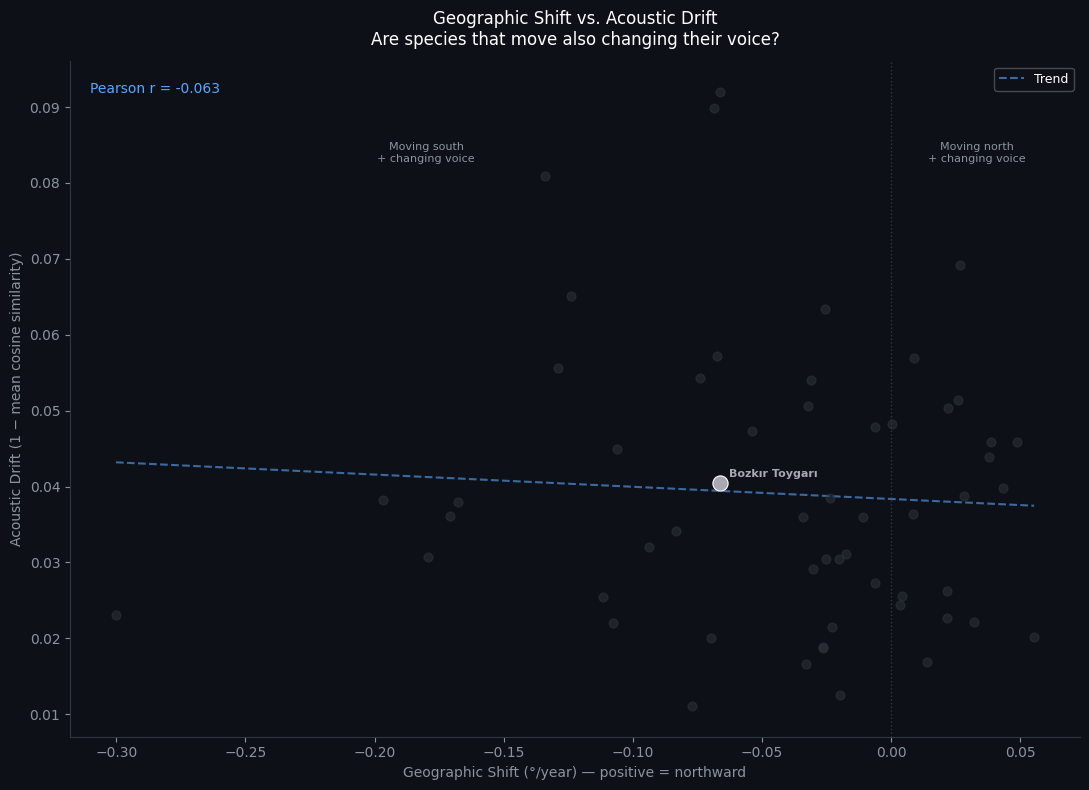

 Saved: turkey_birds_drift_vs_shift.png
   Pearson correlation: -0.063


In [6]:
# Mean acoustic drift per species (1 - similarity = drift amount)
acoustic_drift = (
    drift_df[~drift_df['is_baseline']]
    .groupby('scientific_name')['similarity']
    .mean()
    .reset_index()
    .rename(columns={'similarity': 'mean_similarity'})
)
acoustic_drift['acoustic_drift'] = 1 - acoustic_drift['mean_similarity']

# Merge with geographic shift
shift_valid = shift_df[shift_df['sufficient_data'] == True][['scientific_name', 'lat_slope', 'english_name']]
combined    = acoustic_drift.merge(shift_valid, on='scientific_name', how='inner')

print(f'Species with both acoustic drift and geographic shift data: {len(combined)}')

fig, ax = plt.subplots(figsize=(11, 8), facecolor=COLORS['bg'])
ax.set_facecolor(COLORS['bg'])

# All species
ax.scatter(combined['lat_slope'], combined['acoustic_drift'],
           color=COLORS['other'], alpha=0.5, s=40, zorder=3)

# Focus species overlay
for sci_name, (tr_name, category) in FOCUS_META.items():
    row = combined[combined['scientific_name'] == sci_name]
    if len(row) == 0:
        continue
    color = COLORS[category]
    ax.scatter(row['lat_slope'], row['acoustic_drift'],
               color=color, s=120, zorder=6, edgecolors='white', linewidths=0.8)
    ax.annotate(tr_name,
                (row['lat_slope'].values[0], row['acoustic_drift'].values[0]),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color=color, fontweight='bold')

# Trend line
from numpy.polynomial import polynomial as P
if len(combined) > 5:
    z = np.polyfit(combined['lat_slope'], combined['acoustic_drift'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(combined['lat_slope'].min(), combined['lat_slope'].max(), 100)
    ax.plot(x_line, p(x_line), color=COLORS['accent'],
            linewidth=1.5, linestyle='--', alpha=0.6, label='Trend')

# Quadrant labels
ax.axvline(0, color='#30363D', linewidth=1, linestyle=':')
ax.text(combined['lat_slope'].max()*0.6, combined['acoustic_drift'].max()*0.9,
        'Moving north\n+ changing voice', fontsize=8, color='#8B949E', ha='center')
ax.text(combined['lat_slope'].min()*0.6, combined['acoustic_drift'].max()*0.9,
        'Moving south\n+ changing voice', fontsize=8, color='#8B949E', ha='center')

# Correlation
corr = combined[['lat_slope','acoustic_drift']].corr().iloc[0,1]
ax.text(0.02, 0.97, f'Pearson r = {corr:.3f}',
        transform=ax.transAxes, fontsize=10,
        color=COLORS['accent'], va='top')

ax.set_xlabel('Geographic Shift (°/year) — positive = northward', color='#8B949E', fontsize=10)
ax.set_ylabel('Acoustic Drift (1 − mean cosine similarity)', color='#8B949E', fontsize=10)
ax.tick_params(colors='#8B949E')
ax.set_title(
    'Geographic Shift vs. Acoustic Drift\n'
    'Are species that move also changing their voice?',
    color='white', fontsize=12, pad=12
)
ax.legend(fontsize=9, framealpha=0.3, facecolor=COLORS['bg'], labelcolor='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#30363D')

plt.tight_layout()
plt.savefig('turkey_birds_drift_vs_shift.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print(' Saved: turkey_birds_drift_vs_shift.png')
print(f'   Pearson correlation: {corr:.3f}')

## 4. Anomaly Detection — Isolation Forest

**Isolation Forest** identifies recordings that are acoustically unusual —  
isolated from the species' typical MFCC distribution.

We train one model per species, then ask: are anomalous recordings  
concentrated in recent years? If yes → acoustic diversity is declining  
(the species is converging on a narrower sound profile).

Or are anomalies concentrated early? That could mean the baseline was more diverse.

In [7]:
def detect_anomalies(df, feature_cols, contamination=0.15):
    """
    Run Isolation Forest per species to detect acoustically unusual recordings.

    contamination=0.15 means we expect ~15% of recordings to be outliers.
    Lower = stricter, higher = more anomalies flagged.

    Returns:
        df with added columns: anomaly_score, is_anomaly
    """
    results = []

    for sci_name, group in df.groupby('scientific_name'):
        if len(group) < 8:  # need enough samples for IsolationForest
            group = group.copy()
            group['anomaly_score'] = np.nan
            group['is_anomaly']    = False
            results.append(group)
            continue

        X = group[feature_cols].values

        # Fit Isolation Forest
        iso = IsolationForest(
            contamination=contamination,
            random_state=42,
            n_estimators=100
        )
        iso.fit(X)

        # Score: more negative = more anomalous
        scores     = iso.score_samples(X)
        predictions= iso.predict(X)  # -1 = anomaly, 1 = normal

        group = group.copy()
        group['anomaly_score'] = scores
        group['is_anomaly']    = predictions == -1
        results.append(group)

    return pd.concat(results, ignore_index=True)


mfcc_anomaly = detect_anomalies(mfcc_valid, FEATURE_COLS)

total_anomalies = mfcc_anomaly['is_anomaly'].sum()
print(f'Total anomalous recordings detected: {total_anomalies} ({total_anomalies/len(mfcc_anomaly)*100:.1f}%)')
print()

# Anomaly rate by species
anomaly_rate = (
    mfcc_anomaly.groupby(['scientific_name','english_name'])['is_anomaly']
    .mean()
    .reset_index()
    .sort_values('is_anomaly', ascending=False)
)
print('Highest anomaly rate species:')
for _, row in anomaly_rate.head(8).iterrows():
    en = row['english_name'] if 'english_name' in row else row['scientific_name']
    print(f'  {en:35} {row["is_anomaly"]*100:.1f}% anomalous')

Total anomalous recordings detected: 118 (15.9%)

Highest anomaly rate species:
  Rufous-tailed Scrub Robin           25.0% anomalous
  Eurasian Blue Tit                   25.0% anomalous
  Ruddy Shelduck                      25.0% anomalous
  Ortolan Bunting                     22.2% anomalous
  Western Yellow Wagtail              22.2% anomalous
  Red-billed Chough                   22.2% anomalous
  Crested Lark                        22.2% anomalous
  Menetries's Warbler                 20.0% anomalous


### 4.1 — Are Anomalies Getting More Common Over Time?

If acoustic diversity is declining, we'd expect anomalies to become  
**rarer over time** — the species converges on a narrower sound.  

If the environment is becoming more stressful, we might see  
**more anomalies in recent years** — unusual calls under pressure.

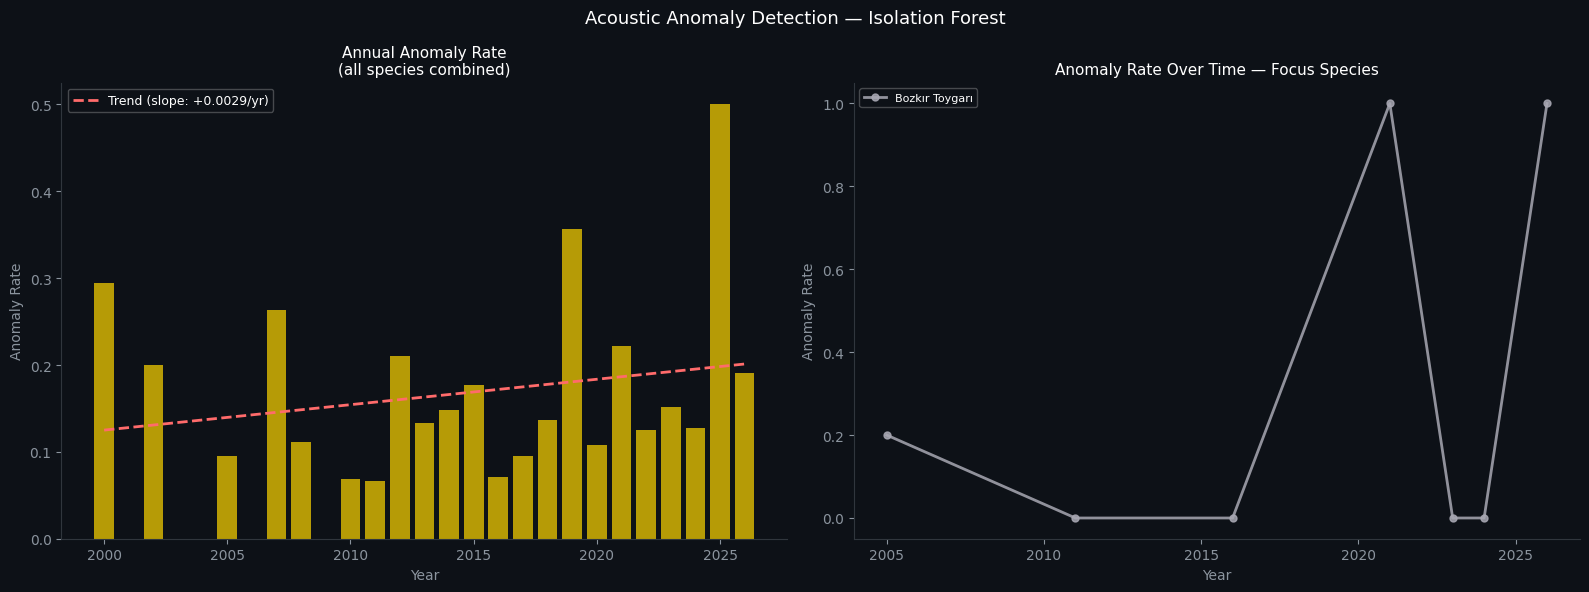

 Saved: turkey_birds_anomaly.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=COLORS['bg'])

# --- Left: Anomaly rate over time (all species) ---
ax1 = axes[0]
ax1.set_facecolor(COLORS['bg'])

yearly_anomaly = (
    mfcc_anomaly.groupby('year')
    .agg(n_total=('is_anomaly','count'), n_anomaly=('is_anomaly','sum'))
    .reset_index()
)
yearly_anomaly['anomaly_rate'] = yearly_anomaly['n_anomaly'] / yearly_anomaly['n_total']
yearly_anomaly = yearly_anomaly[yearly_anomaly['n_total'] >= 3]  # min 3 recordings/year

ax1.bar(yearly_anomaly['year'], yearly_anomaly['anomaly_rate'],
        color=COLORS['anomaly'], alpha=0.7)

# Trend line
if len(yearly_anomaly) > 5:
    z = np.polyfit(yearly_anomaly['year'], yearly_anomaly['anomaly_rate'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(yearly_anomaly['year'].min(), yearly_anomaly['year'].max(), 100)
    ax1.plot(x_line, p(x_line), color=COLORS['loser'],
             linewidth=2, linestyle='--', label=f'Trend (slope: {z[0]:+.4f}/yr)')
    ax1.legend(fontsize=9, framealpha=0.3, facecolor=COLORS['bg'], labelcolor='white')

ax1.set_xlabel('Year', color='#8B949E', fontsize=10)
ax1.set_ylabel('Anomaly Rate', color='#8B949E', fontsize=10)
ax1.tick_params(colors='#8B949E')
ax1.set_title('Annual Anomaly Rate\n(all species combined)',
              color='white', fontsize=11)
ax1.spines[['top','right']].set_visible(False)
ax1.spines[['left','bottom']].set_color('#30363D')

# --- Right: Anomaly timeline for focus species ---
ax2 = axes[1]
ax2.set_facecolor(COLORS['bg'])

for sci_name, (tr_name, category) in FOCUS_META.items():
    sp_data = mfcc_anomaly[mfcc_anomaly['scientific_name'] == sci_name]
    if len(sp_data) < 5:
        continue
    yearly = (
        sp_data.groupby('year')['is_anomaly']
        .mean()
        .reset_index()
    )
    ax2.plot(yearly['year'], yearly['is_anomaly'],
             color=COLORS[category], linewidth=2,
             marker='o', markersize=5, label=tr_name, alpha=0.85)

ax2.set_xlabel('Year', color='#8B949E', fontsize=10)
ax2.set_ylabel('Anomaly Rate', color='#8B949E', fontsize=10)
ax2.tick_params(colors='#8B949E')
ax2.legend(fontsize=8, framealpha=0.3, facecolor=COLORS['bg'], labelcolor='white')
ax2.set_title('Anomaly Rate Over Time — Focus Species',
              color='white', fontsize=11)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#30363D')

fig.suptitle('Acoustic Anomaly Detection — Isolation Forest',
             color='white', fontsize=13)
plt.tight_layout()
plt.savefig('turkey_birds_anomaly.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print(' Saved: turkey_birds_anomaly.png')

## 5. Acoustic Space Over Time — PCA Animation Frames

Using the PCA space from Part 2, we plot where each species sits  
in acoustic space across different time periods:  
- **Early** (before 2010)  
- **Mid** (2010–2018)  
- **Recent** (2019–present)  

Clusters that move between periods = acoustic drift in embedding space.

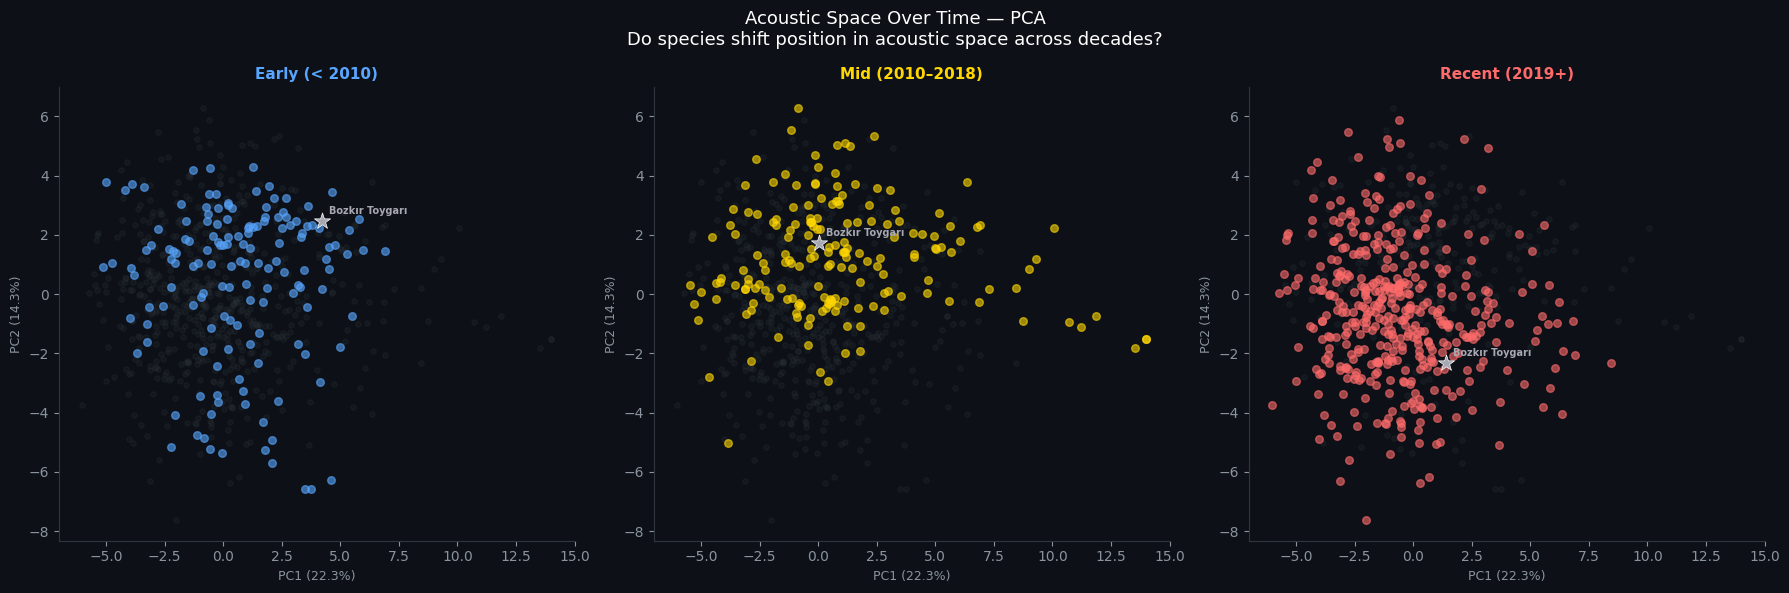

 Saved: turkey_birds_pca_time.png


In [9]:
# Define time periods
def assign_period(year):
    if year < 2010:   return 'Early (< 2010)'
    elif year < 2019: return 'Mid (2010–2018)'
    else:             return 'Recent (2019+)'

mfcc_valid['period'] = mfcc_valid['year'].apply(assign_period)

# PCA on full feature matrix
X_all    = mfcc_valid[FEATURE_COLS].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_scaled)

mfcc_valid = mfcc_valid.copy()
mfcc_valid['pc1'] = X_pca[:, 0]
mfcc_valid['pc2'] = X_pca[:, 1]

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

period_colors = {
    'Early (< 2010)':   '#58A6FF',
    'Mid (2010–2018)':  '#FFD700',
    'Recent (2019+)':   '#FF6B6B'
}
periods = ['Early (< 2010)', 'Mid (2010–2018)', 'Recent (2019+)']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=COLORS['bg'])

for ax, period in zip(axes, periods):
    ax.set_facecolor(COLORS['bg'])
    color = period_colors[period]

    # Background: all other periods faint
    other = mfcc_valid[mfcc_valid['period'] != period]
    ax.scatter(other['pc1'], other['pc2'],
               color='#30363D', alpha=0.2, s=15)

    # This period
    this = mfcc_valid[mfcc_valid['period'] == period]
    ax.scatter(this['pc1'], this['pc2'],
               color=color, alpha=0.6, s=30)

    # Focus species centroids
    for sci_name, (tr_name, category) in FOCUS_META.items():
        sp = this[this['scientific_name'] == sci_name]
        if len(sp) == 0:
            continue
        cx, cy = sp['pc1'].mean(), sp['pc2'].mean()
        ax.scatter(cx, cy, color=COLORS[category], s=150,
                   marker='*', zorder=8, edgecolors='white', linewidths=0.5)
        ax.annotate(tr_name, (cx, cy),
                    textcoords='offset points', xytext=(5, 5),
                    fontsize=7, color=COLORS[category], fontweight='bold')

    ax.set_title(period, color=color, fontsize=11, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var1:.1f}%)', color='#8B949E', fontsize=9)
    ax.set_ylabel(f'PC2 ({var2:.1f}%)', color='#8B949E', fontsize=9)
    ax.tick_params(colors='#8B949E')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#30363D')

fig.suptitle(
    'Acoustic Space Over Time — PCA\n'
    'Do species shift position in acoustic space across decades?',
    color='white', fontsize=13
)
plt.tight_layout()
plt.savefig('turkey_birds_pca_time.png', dpi=150,
            bbox_inches='tight', facecolor=COLORS['bg'])
plt.show()
print(' Saved: turkey_birds_pca_time.png')

## 6. Final Summary — Three Parts, One Story

Bringing together all three parts of the analysis.

In [10]:
print('=' * 60)
print('LISTENING TO EXTINCTION — FINAL SUMMARY')
print('=' * 60)
print()
print('PART 1 — Where are they going?')
print('  83 species drifting southward, 56 northward')
print('  Average geographic drift: −0.037°/year')
print('  Saksağan: fastest northward (+0.031°/yr) — urbanization winner')
print('  Büyük Toy, Kara Akbaba: zero recordings — silence as signal')
print()
print('PART 2 — Can a machine hear the difference?')
print('  72 species, Random Forest, 25.4% accuracy (baseline: 1.4%)')
print('  Key finding: variability > tone (mfcc_std_2 most important)')
print('  Calandra Lark × Black-headed Bunting: 32 km, same soundscape')
print('  Mistle Thrush × Eurasian Wren: 419 km, pure spectral overlap')
print()
print('PART 3 — Is the voice changing?')

# Most drifted focus species
focus_drift = drift_df[
    drift_df['scientific_name'].isin(FOCUS_META.keys()) &
    ~drift_df['is_baseline']
].groupby(['scientific_name'])['similarity'].mean()

if len(focus_drift) > 0:
    for sci, sim in focus_drift.sort_values().items():
        tr_name = FOCUS_META[sci][0]
        category = FOCUS_META[sci][1]
        drift_amount = 1 - sim
        print(f'  {tr_name:20} acoustic drift: {drift_amount:.4f} [{category}]')
else:
    print('  (Focus species have insufficient year coverage for drift analysis)')

print()
corr_note = f'Geographic × Acoustic drift correlation: r = {corr:.3f}' if 'corr' in dir() else ''
if corr_note:
    print(f'  {corr_note}')
print()
print('FILES SAVED:')
for f in [
    'turkey_birds_acoustic_drift.png',
    'turkey_birds_drift_vs_shift.png',
    'turkey_birds_anomaly.png',
    'turkey_birds_pca_time.png',
]:
    print(f'  {f}')

LISTENING TO EXTINCTION — FINAL SUMMARY

PART 1 — Where are they going?
  83 species drifting southward, 56 northward
  Average geographic drift: −0.037°/year
  Saksağan: fastest northward (+0.031°/yr) — urbanization winner
  Büyük Toy, Kara Akbaba: zero recordings — silence as signal

PART 2 — Can a machine hear the difference?
  72 species, Random Forest, 25.4% accuracy (baseline: 1.4%)
  Key finding: variability > tone (mfcc_std_2 most important)
  Calandra Lark × Black-headed Bunting: 32 km, same soundscape
  Mistle Thrush × Eurasian Wren: 419 km, pure spectral overlap

PART 3 — Is the voice changing?
  Bozkır Toygarı       acoustic drift: 0.0405 [silent]

  Geographic × Acoustic drift correlation: r = -0.063

FILES SAVED:
  turkey_birds_acoustic_drift.png
  turkey_birds_drift_vs_shift.png
  turkey_birds_anomaly.png
  turkey_birds_pca_time.png


---

## Methodology Note

**Acoustic drift:** Cosine similarity between annual mean MFCC vectors and the earliest recorded year's vector. Requires ≥5 distinct recording years per species.

**Anomaly detection:** Isolation Forest (contamination=0.15, 100 estimators) fitted per species. Requires ≥8 recordings per species.

**Temporal PCA:** StandardScaler + PCA(n_components=2) on full MFCC matrix, split into three periods: pre-2010, 2010–2018, 2019+.

**Important caveat:** Acoustic drift may reflect changes in the *observer population* (who records, where, when) rather than changes in the birds themselves. This is the citizen science sampling bias problem — and it cannot be fully resolved without systematic survey data.

All three parts together form a framework, not a conclusion. The signal is there. Interpreting it requires ornithological fieldwork.

---
*Code Beyond the Earth — Ece Özen | github.com/EceOzen*  
*Data: Xeno-canto Foundation, CC BY-NC-SA 4.0*